# Cian ETH Vault Analysis

Analyzes transaction patterns and token flows for the Cian ETH yield vault (`0xB13aa2d0345b0439b064f26B82D8dCf3f508775d`).

## Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('../src').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
from yield_aggregators.cian_analysis import (
    plot_cumulative_token_flow_usd,
    plot_combined_aave_flows_usd
)

function_signatures = {
    "redeem": ["0xa7b73254"],
    "deposit": ["0x32507a5f"],
    "strategy_investment": ["0xba8bfa2a"],
    "multicall": ["0xda5b4ffd"],
}

cian_vault_address = "0xB13aa2d0345b0439b064f26B82D8dCf3f508775d".lower()
manager_contract_address = "0x6d425B3D302DD82cC611866eC8176d435307b616".lower()

In [2]:
eth_usd_csv_path = '../data/exchange_rates/eth_usd.csv'

cian_transactions = pd.read_csv('../data/cian_vault_transactions.csv')
print(f"Loaded {len(cian_transactions):,} transactions")

steth_transfers = pd.read_csv('../data/cian_steth_transfers.csv')
steth_transfers['datetime'] = pd.to_datetime(steth_transfers['datetime'])

weth_transfers = pd.read_csv('../data/cian_weth_transfers.csv')
weth_transfers['datetime'] = pd.to_datetime(weth_transfers['datetime'])

wsteth_transfers = pd.read_csv('../data/cian_wsteth_transfers.csv')
wsteth_transfers['datetime'] = pd.to_datetime(wsteth_transfers['datetime'])

ezeth_transfers = pd.read_csv('../data/cian_ezeth_transfers.csv')
ezeth_transfers['datetime'] = pd.to_datetime(ezeth_transfers['datetime'])

eth_transfers = pd.read_csv('../data/cian_eth_transfers.csv')
eth_transfers['datetime'] = pd.to_datetime(eth_transfers['datetime'])

# Order matters: indices are used by calculate_combined_aave_flows
cian_transfer_dataframes = [steth_transfers, weth_transfers, wsteth_transfers, ezeth_transfers, eth_transfers]

cian_token_transfers = pd.concat(cian_transfer_dataframes, ignore_index=True)
print(f"Loaded {len(cian_token_transfers):,} token transfers")

Loaded 152,125 transactions
Loaded 1,963 token transfers


/var/folders/4r/m98p1dyn123bfvxx30k78gmw0000gn/T/ipykernel_10705/3595888836.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  cian_transactions = pd.read_csv('../data/cian_vault_transactions.csv')


## Data Overview

Total transactions and token transfers, broken down by function signature.

In [3]:
total_unique_txs = cian_transactions['tx_hash'].nunique()
total_token_transfers = len(cian_token_transfers)

print("="*70)
print("OVERALL DATA SUMMARY")
print("="*70)
print(f"Total unique transactions: {total_unique_txs:,}")
print(f"Total token transfers:      {total_token_transfers:,}")
print("="*70)

cian_transactions['function_signature'] = cian_transactions['input'].astype(str).str[:10]
cian_transactions['to_normalized'] = cian_transactions['to_address'].astype(str).str.lower()

print("\n" + "="*70)
print("BREAKDOWN BY FUNCTION (directed at vault or manager)")
print("="*70)

for func_name, signatures in function_signatures.items():
    func_txs = cian_transactions[
        (cian_transactions['function_signature'].isin(signatures)) &
        ((cian_transactions['to_normalized'] == cian_vault_address) |
         (cian_transactions['to_normalized'] == manager_contract_address))
    ]
    unique_tx_hashes = func_txs['tx_hash'].unique()
    func_transfers = cian_token_transfers[cian_token_transfers['tx_hash'].isin(unique_tx_hashes)]
    
    print(f"\n{func_name.upper()}")
    print(f"  Signatures: {', '.join(signatures)}")
    print(f"  Transactions:     {len(unique_tx_hashes):>6,}")
    print(f"  Token transfers:  {len(func_transfers):>6,}")

print("\n" + "="*70)

OVERALL DATA SUMMARY
Total unique transactions: 921
Total token transfers:      1,963

BREAKDOWN BY FUNCTION (directed at vault or manager)

REDEEM
  Signatures: 0xa7b73254
  Transactions:         31
  Token transfers:     166

DEPOSIT
  Signatures: 0x32507a5f
  Transactions:        159
  Token transfers:     430

STRATEGY_INVESTMENT
  Signatures: 0xba8bfa2a
  Transactions:         12
  Token transfers:      44

MULTICALL
  Signatures: 0xda5b4ffd
  Transactions:        362
  Token transfers:   1,078



## Deposit & Withdrawal Statistics

Summary statistics for deposits and withdrawals in USD. Includes transfer depth and internal call depth analysis.

In [4]:
from yield_aggregators.cian_analysis import calculate_deposit_withdrawal_statistics

calculate_deposit_withdrawal_statistics(
    transactions_df=cian_transactions,
    transfers_df_list=cian_transfer_dataframes,
    function_signatures=function_signatures,
    vault_address=cian_vault_address,
    eth_usd_csv_path=eth_usd_csv_path,
    start_date='2024-05-01',
    end_date='2025-05-01',
    deduplicate_by_tx_hash=True  # Prevents double-counting wstETH->stETH unwraps
)

DEPOSIT AND WITHDRAWAL STATISTICS (USD)

----------------------------------------------------------------------
OVERALL SUMMARY
----------------------------------------------------------------------
Total Deposits:     $  53,996,951.54
Total Withdrawals:  $  17,585,987.68
Net Flow:           $  36,410,963.86

----------------------------------------------------------------------
DEPOSIT STATISTICS (individual transfers)
----------------------------------------------------------------------
Count:                          159
Mean:               $     339,603.47
Median:             $       2,685.01
Std Dev:            $   1,359,730.64
Min:                $          24.16
25th Percentile:    $         386.36
75th Percentile:    $      49,374.91
Max:                $  10,055,349.15

----------------------------------------------------------------------
WITHDRAWAL STATISTICS (individual transfers)
----------------------------------------------------------------------
Count:                

In [5]:
from yield_aggregators.cian_analysis import export_deposit_withdrawal_transfers

deposit_df, withdrawal_df = export_deposit_withdrawal_transfers(
    transactions_df=cian_transactions,
    transfers_df_list=cian_transfer_dataframes,
    function_signatures=function_signatures,
    vault_address=cian_vault_address,
    eth_usd_csv_path=eth_usd_csv_path,
    output_dir='../results/raw_data',
    start_date='2024-05-01',
    end_date='2025-05-01',
    deduplicate_by_tx_hash=True  # Prevents double-counting wstETH->stETH unwraps
)

EXPORTED DEPOSIT AND WITHDRAWAL DATA
Deposits exported:        159 records -> ../results/raw_data/cian_deposits.csv
Withdrawals exported:      37 records -> ../results/raw_data/cian_withdrawals.csv


In [6]:
from yield_aggregators.cian_analysis import (
    calculate_transaction_depth_statistics,
    print_transaction_depth_statistics,
)

depth_stats = calculate_transaction_depth_statistics(
    transactions_df=cian_transactions,
    transfers_df_list=cian_transfer_dataframes,
    function_signatures=function_signatures,
)

print_transaction_depth_statistics(depth_stats)


TRANSACTION DEPTH STATISTICS (token transfers per tx hash)

REDEEM
  Transactions:          31
  Mean:                5.35
  Median:              5.00
  Min:                    3
  Max:                   11

DEPOSIT
  Transactions:         159
  Mean:                2.70
  Median:              3.00
  Min:                    1
  Max:                    8

STRATEGY INVESTMENT
  Transactions:          12
  Mean:                3.67
  Median:              3.00
  Min:                    1
  Max:                    7

MULTICALL
  Transactions:         185
  Mean:                5.87
  Median:              4.00
  Min:                    1
  Max:                   34




In [7]:
from yield_aggregators.cian_analysis import (
    calculate_internal_tx_depth_statistics,
    print_internal_tx_depth_statistics,
)

internal_depth_stats = calculate_internal_tx_depth_statistics(
    transactions_df=cian_transactions,
    function_signatures=function_signatures,
)

print_internal_tx_depth_statistics(internal_depth_stats)


INTERNAL TRANSACTION DEPTH STATISTICS (traces per tx hash)

REDEEM
  Transactions:          39
  Mean:              465.23
  Median:            703.00
  Min:                   18
  Max:                  915

DEPOSIT
  Transactions:         171
  Mean:                5.15
  Median:              3.00
  Min:                    3
  Max:                   26

STRATEGY INVESTMENT
  Transactions:          14
  Mean:              375.07
  Median:             66.00
  Min:                   19
  Max:                  872

MULTICALL
  Transactions:         371
  Mean:              366.68
  Median:            184.00
  Min:                    3
  Max:                  930




## Net Deposits vs. Withdrawals

Cumulative USD value deposited and withdrawn from the vault over time.

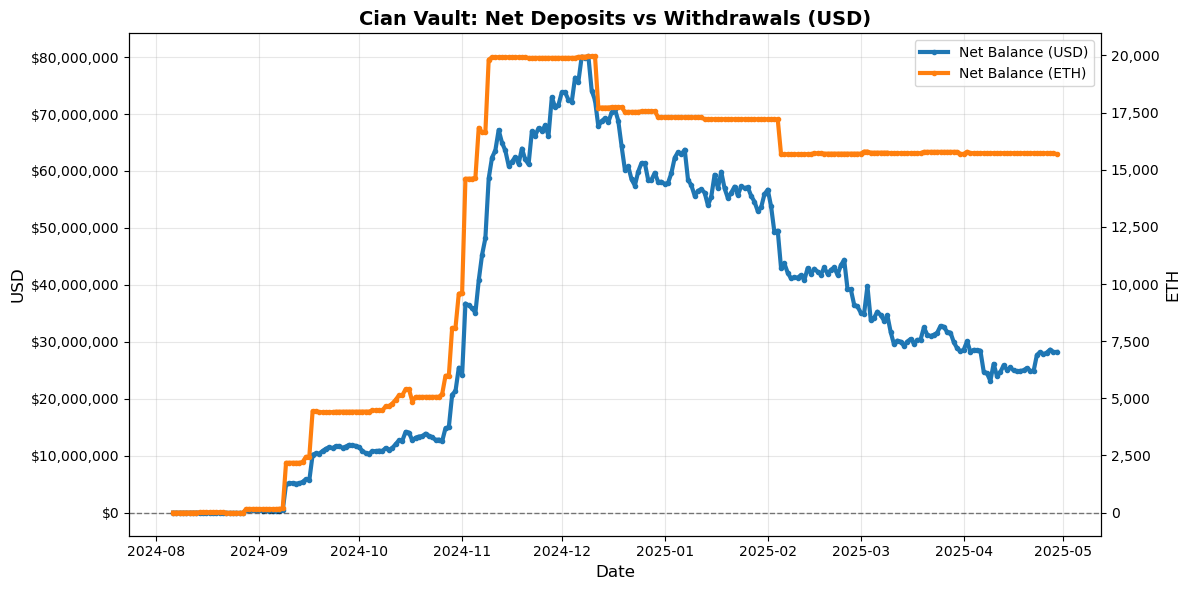

In [8]:
fig = plot_cumulative_token_flow_usd(
    transactions_df=cian_transactions,
    transfers_df_list=cian_transfer_dataframes,
    function_signatures=function_signatures,
    vault_address=cian_vault_address,
    eth_usd_csv_path=eth_usd_csv_path,
    start_date='2024-05-01',
    end_date='2025-05-01',
    freq='D',
    title='Cian Vault: Net Deposits vs Withdrawals (USD)',
    figsize=(12, 6)
)

plt.show()

In [9]:
from yield_aggregators.cian_analysis import export_cumulative_flow_to_csv

export_cumulative_flow_to_csv(
    transactions_df=cian_transactions,
    transfers_df_list=cian_transfer_dataframes,
    function_signatures=function_signatures,
    vault_address=cian_vault_address,
    eth_usd_csv_path=eth_usd_csv_path,
    output_path='../results/raw_data/cian_net_deposits.csv',
    start_date='2024-05-01',
    end_date='2025-05-01'
)

Data exported to: ../results/raw_data/cian_net_deposits.csv


## Deleveraged Assets

Cumulative USD value of assets across Aave positions, after unwinding leverage.


DELEVERAGED CIAN ASSETS (USD)
Final flow:    $25,095,205.21 USD
Maximum flow:  $75,276,042.80 USD
Minimum flow:  $  226,731.24 USD


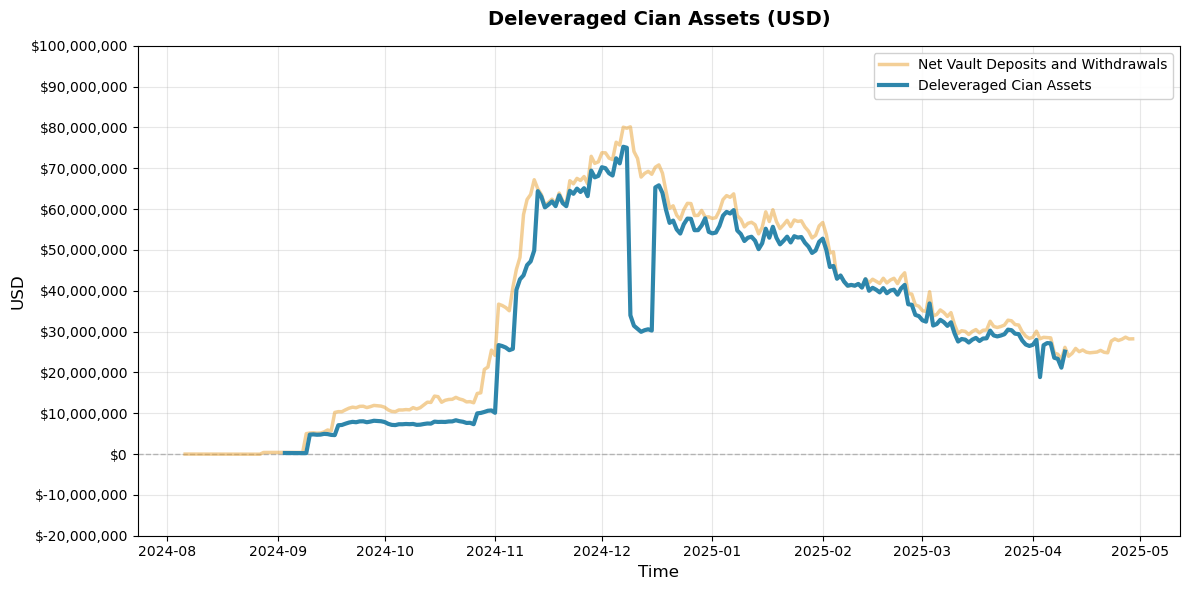

In [10]:
fig = plot_combined_aave_flows_usd(
    transactions_df=cian_transactions,
    transfers_df_list=cian_transfer_dataframes,
    function_signatures=function_signatures,
    vault_address=cian_vault_address,
    eth_usd_csv_path=eth_usd_csv_path,
    exchange_rates_dir='../data/exchange_rates',
    start_date='2024-05-01',
    end_date='2025-05-01',
    freq='D',
    title='Deleveraged Cian Assets (USD)',
    figsize=(12, 6)
)

plt.show()

In [11]:
from yield_aggregators.cian_analysis import export_deleveraged_assets_to_csv

export_deleveraged_assets_to_csv(
    transactions_df=cian_transactions,
    transfers_df_list=cian_transfer_dataframes,
    function_signatures=function_signatures,
    vault_address=cian_vault_address,
    eth_usd_csv_path=eth_usd_csv_path,
    output_path='../results/raw_data/cian_deleveraged_assets.csv',
    exchange_rates_dir='../data/exchange_rates',
    start_date='2024-05-01',
    end_date='2025-05-01'
)

Data exported to: ../results/raw_data/cian_deleveraged_assets.csv


## stETH Transfer Network

Graph of stETH token flows during `transfer_to_strategy` operations, showing how stETH moves from the vault to yield strategies.

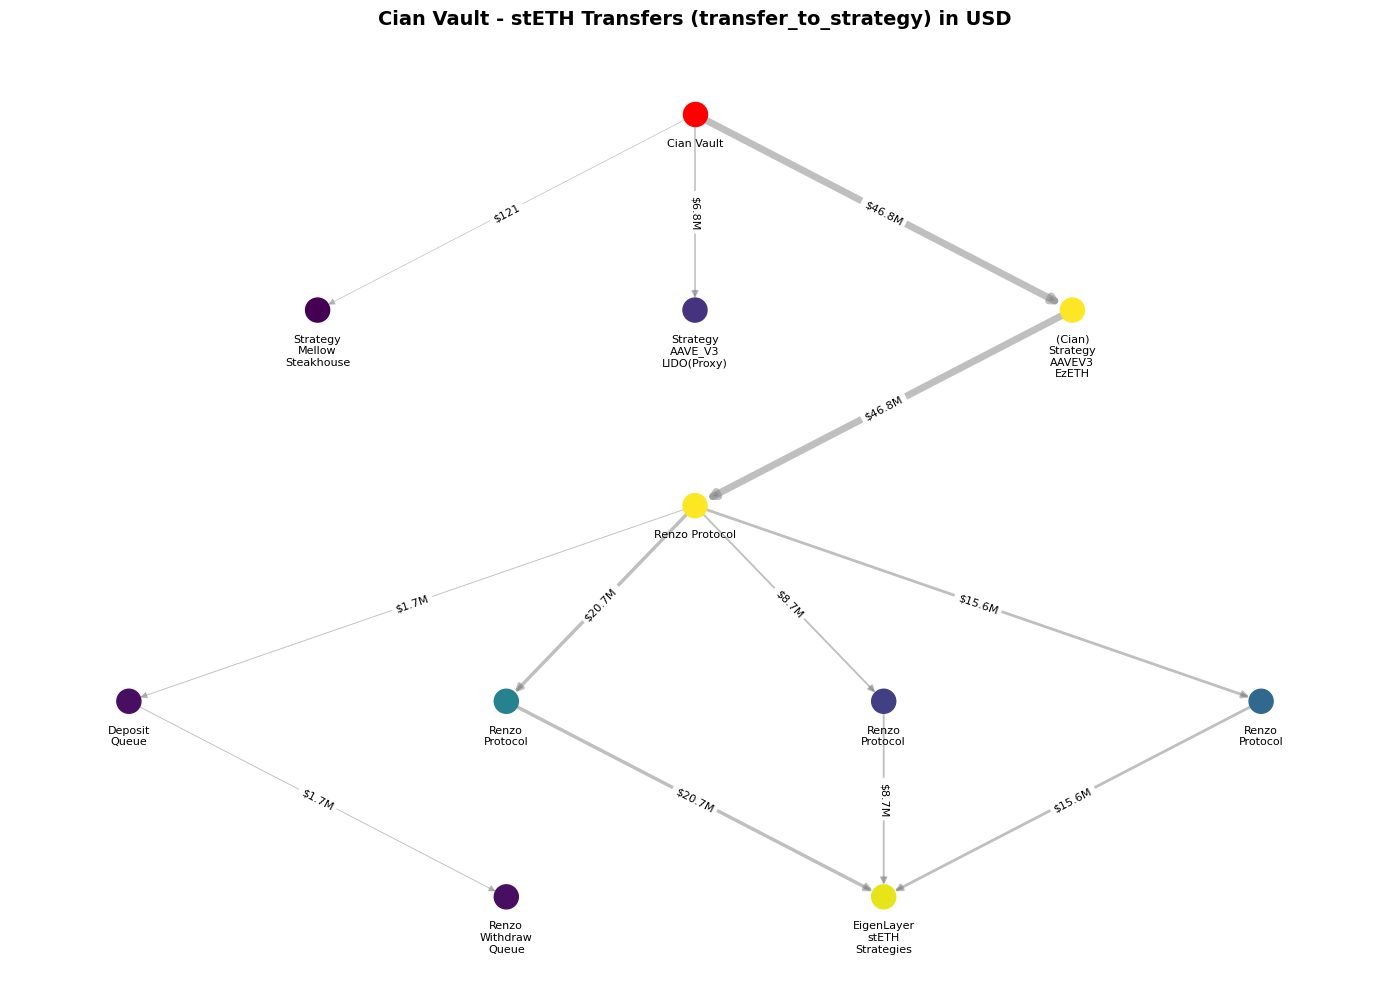

In [12]:
from yield_aggregators.cian_network_visualization import plot_steth_transfer_to_strategy_network

fig = plot_steth_transfer_to_strategy_network(
    steth_transfers=cian_transfer_dataframes[0],  # stETH is at index 0
    vault_transactions=cian_transactions,
    vault_address=cian_vault_address,
    title='Cian Vault - stETH Transfers (transfer_to_strategy) in USD',
    figsize=(14, 10),
    show_node_labels=True,
    show_edge_labels=True,
    convert_to_usd=True,
    exchange_rates_dir='../data/exchange_rates'
)

plt.show()

## Single Transaction Network

Token transfer graph for a specific transaction, showing all token movements across stETH, WETH, ezETH, and wstETH.

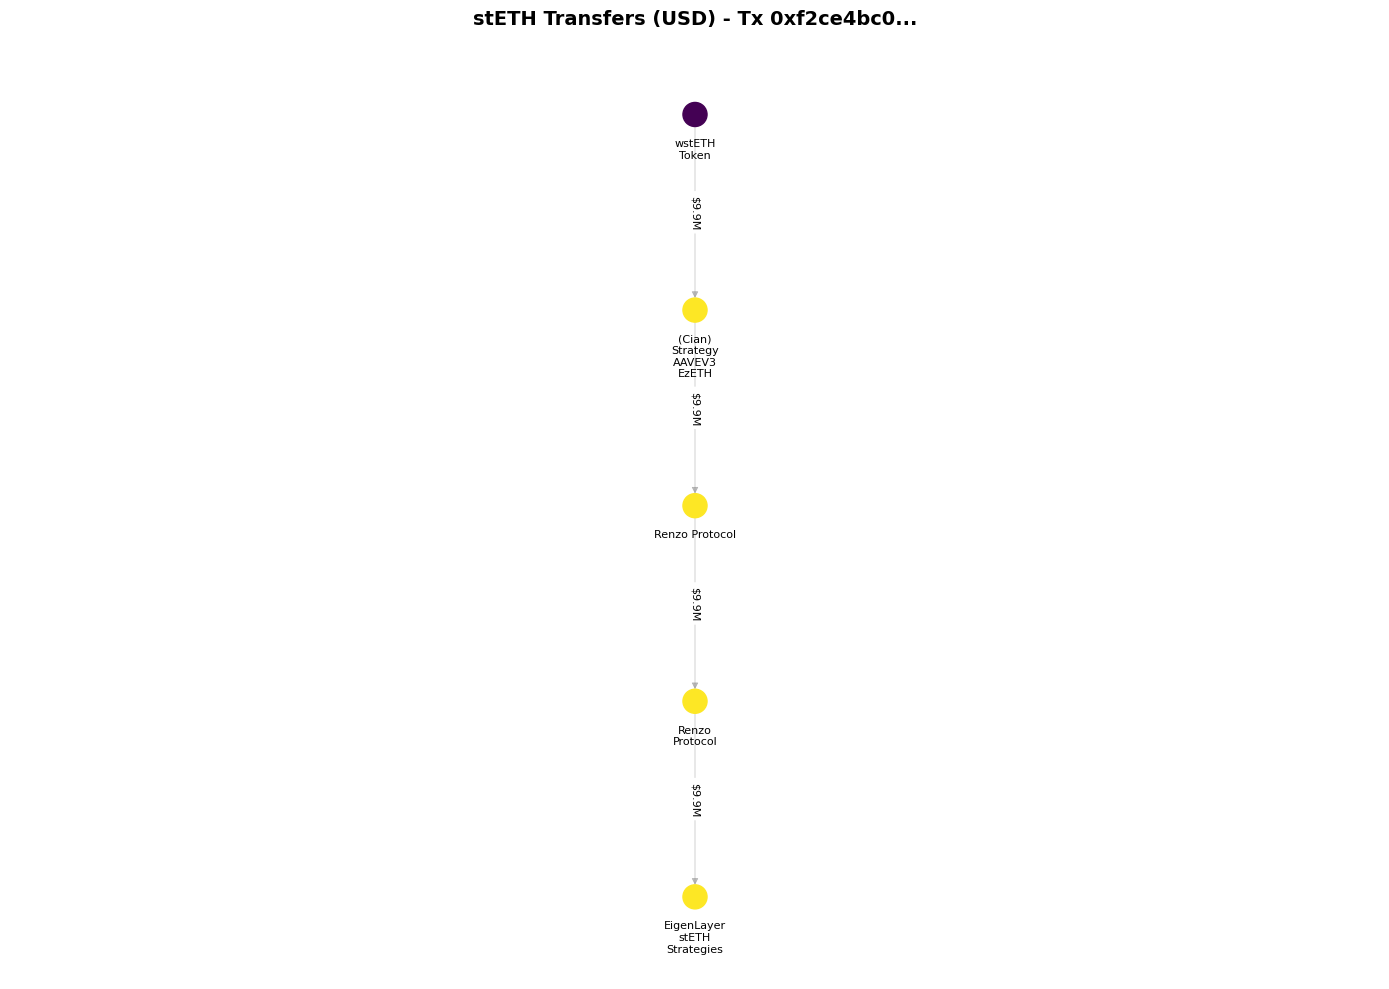

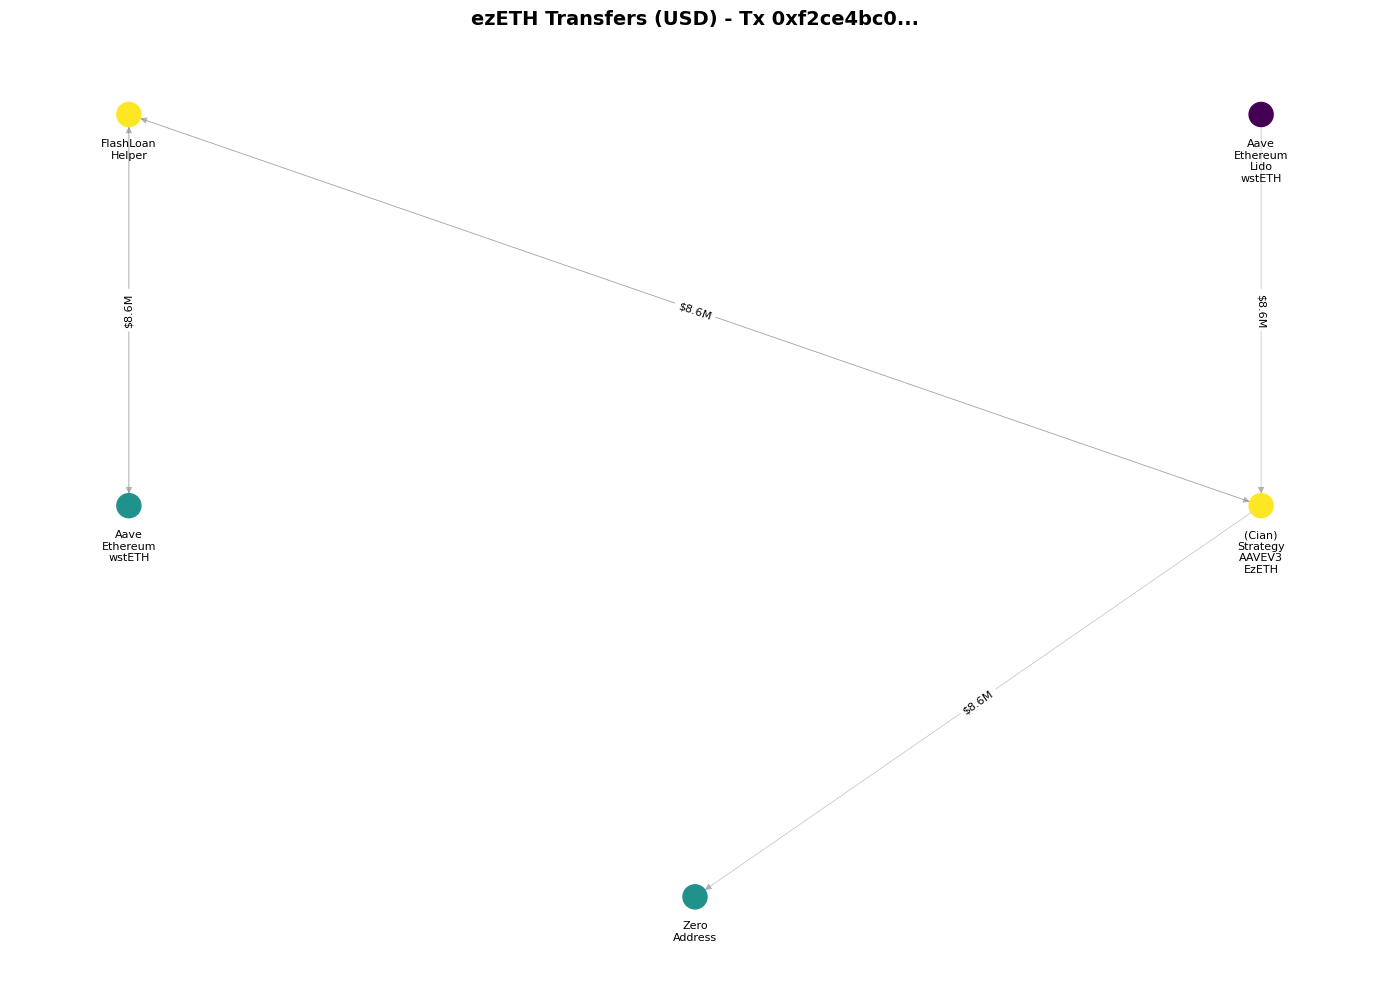

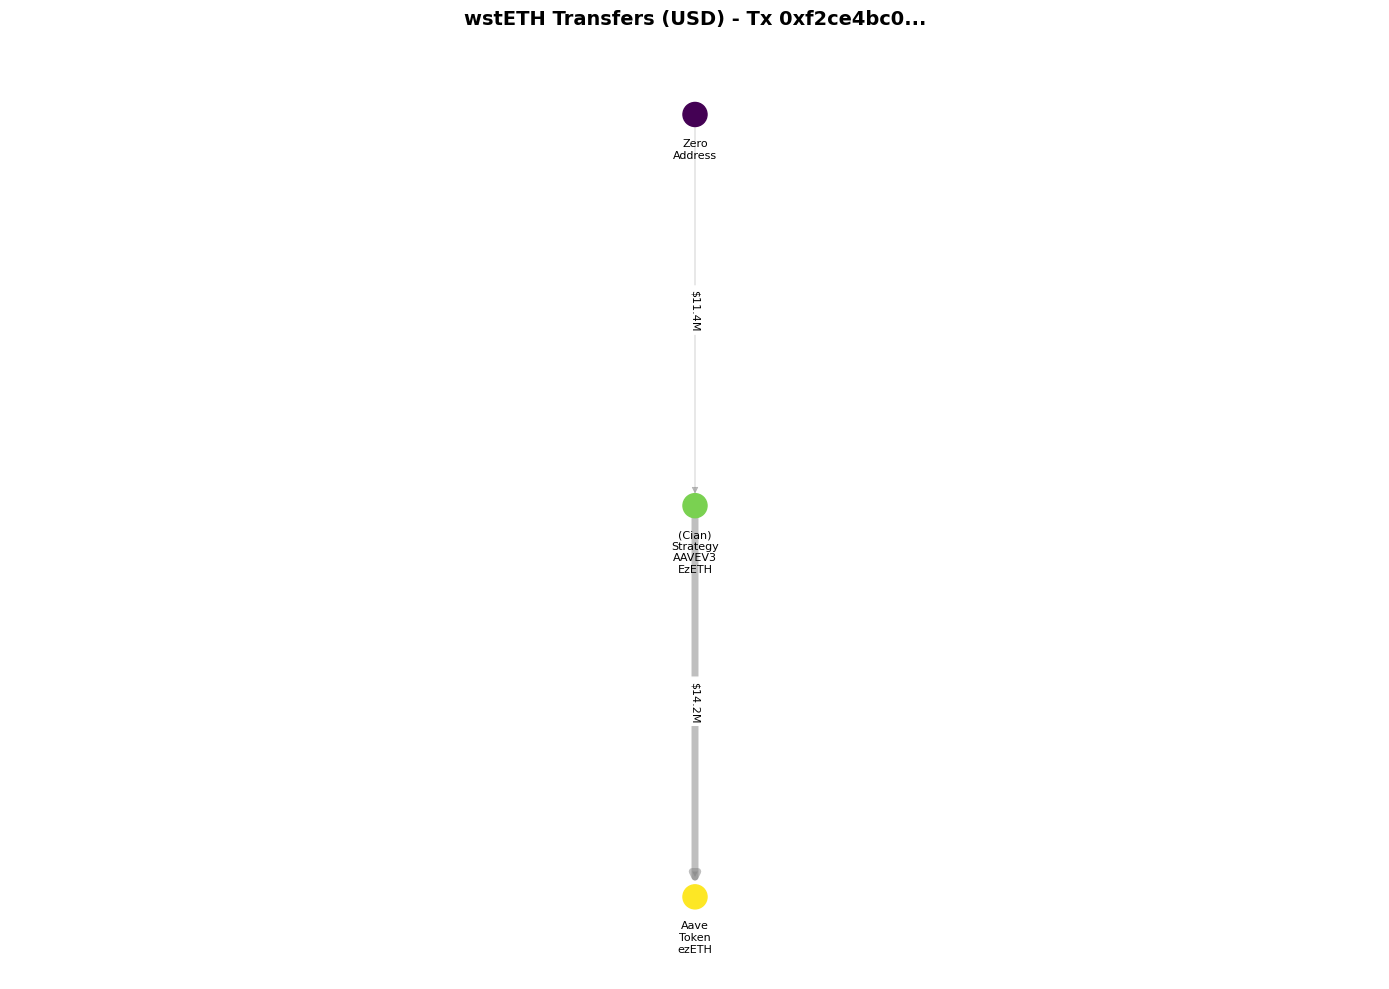

In [13]:
from yield_aggregators.cian_network_visualization import plot_transaction_network

tx_hash = '0xf2ce4bc0e749465221788d32877f3bfca1163d9eed5d4ff57e8d8eaee069c649'

# (dataframe, token_name, exchange_rate_file)
token_configs = [
    (cian_transfer_dataframes[0], 'stETH', 'eth_usd.csv'),
    (cian_transfer_dataframes[1], 'WETH', 'eth_usd.csv'),
    (cian_transfer_dataframes[2], 'ezETH', 'ezeth_usd.csv'),
    (cian_transfer_dataframes[3], 'wstETH', 'wsteth_usd.csv')
]

for transfers_df, token_name, exchange_file in token_configs:
    fig = plot_transaction_network(
        transfers_df=transfers_df,
        transaction_hash=tx_hash,
        token_name=token_name,
        vault_address=cian_vault_address,
        figsize=(14, 10),
        show_node_labels=True,
        show_edge_labels=True,
        convert_to_usd=True,
        exchange_rates_dir='../data/exchange_rates',
        exchange_rate_file=exchange_file,
        address_labels_path='../data/address_labels.json'
    )
    
    if fig is not None:
        plt.show()

## Vault Exchange Rate

Assets per share over time, reflecting yield accrual.


CIAN VAULT EXCHANGE RATE ANALYSIS
Starting rate: 1.000000 ETH per share
Ending rate:   1.051262 ETH per share
Total change:  +5.13%

Annualized rate (projected from data until 2025-04-11): +4.22% per year


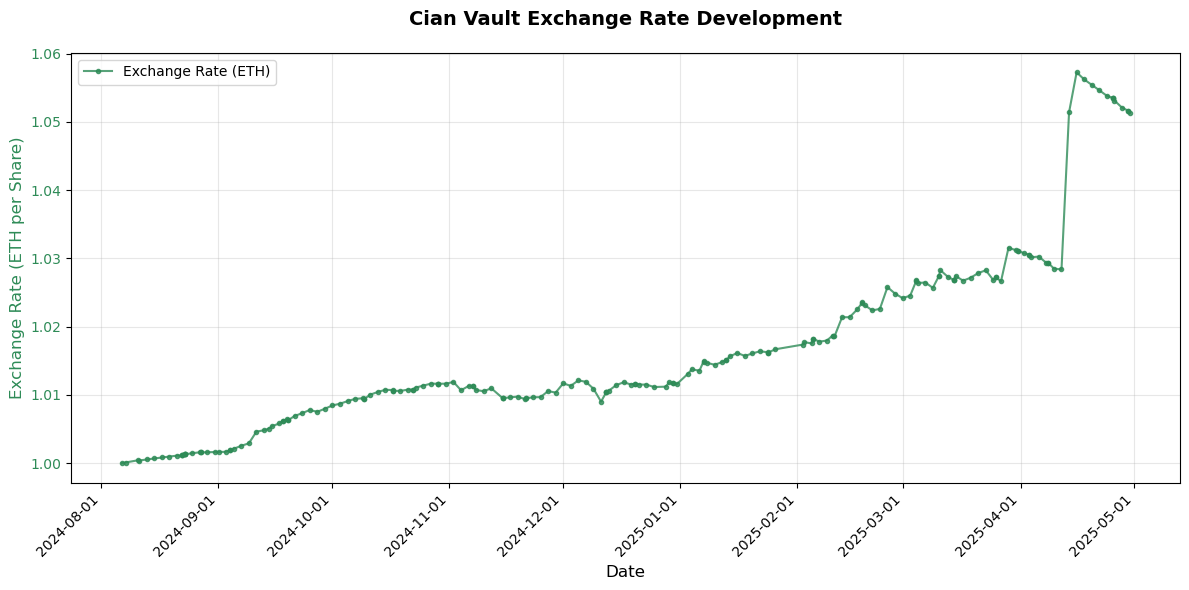

In [14]:
cian_exchange_df = pd.read_csv('../data/cian_exchange_price_df.csv')

from yield_aggregators.cian_analysis import plot_cian_vault_exchange_rate_over_time

fig = plot_cian_vault_exchange_rate_over_time(
    cian_exchange_df=cian_exchange_df,
    time_column='datetime',
    freq='D',
    title='Cian Vault Exchange Rate Development',
    figsize=(12, 6),
    start_date='2024-08-01',
    end_date='2025-05-01'
)

plt.show()